# Sawtooth evaluation tables

Generates publication-style PNG/PDF tables from `metrics.csv`.

Outputs are saved directly in `EVAL_DIR`.

In [1]:
from pathlib import Path
import os

import pandas as pd
import matplotlib.pyplot as plt

REPO_ROOT = Path("/scratch2/ij292/tnp-crps").resolve()
os.chdir(REPO_ROOT)

EVAL_DIR = REPO_ROOT / "results/synthetic_1d/sawtooth_ambiguous_eval"
EVAL_DIR.mkdir(parents=True, exist_ok=True)

metrics_path = EVAL_DIR / "metrics.csv"
metrics_raw = pd.read_csv(metrics_path)

print("Loaded:", metrics_path)
print("Shape before filtering:", metrics_raw.shape)
print("Columns:", list(metrics_raw.columns))

metrics_raw.head()


Loaded: /scratch2/ij292/tnp-crps/results/synthetic_1d/sawtooth_ambiguous_eval/metrics.csv
Shape before filtering: (27, 165)
Columns: ['model_name', 'eval_set', 'region', 'context_bucket', 'num_eval_samples', 'numel', 'rmse_pooled', 'crps', 'energy_score', 'ensemble_spread', 'spread_skill_ratio', 'sample_diversity_offdiag', 'coverage_50', 'coverage_80', 'coverage_90', 'coverage_95', 'width_50', 'width_80', 'width_90', 'width_95', 'checkpoint_path', 'sse', 'crps_sum', 'var_sum', 'diversity_sum', 'energy_score_sum', 'energy_score_num_tasks', 'coverage_count_50', 'width_sum_50', 'coverage_count_80', 'width_sum_80', 'coverage_count_90', 'width_sum_90', 'coverage_count_95', 'width_sum_95', 'rank_000', 'rank_001', 'rank_002', 'rank_003', 'rank_004', 'rank_005', 'rank_006', 'rank_007', 'rank_008', 'rank_009', 'rank_010', 'rank_011', 'rank_012', 'rank_013', 'rank_014', 'rank_015', 'rank_016', 'rank_017', 'rank_018', 'rank_019', 'rank_020', 'rank_021', 'rank_022', 'rank_023', 'rank_024', 'rank_0

,model_name,eval_set,region,context_bucket,num_eval_samples,numel,rmse_pooled,crps,energy_score,ensemble_spread,...,rank_055_prob,rank_056_prob,rank_057_prob,rank_058_prob,rank_059_prob,rank_060_prob,rank_061_prob,rank_062_prob,rank_063_prob,rank_064_prob
0,sawtooth_ambiguous_dropout_crps_m4_p010,sawtooth_ambiguous,all,all,64,524288,0.290412,0.166378,2.598812,0.289279,...,0.014639,0.014427,0.014576,0.014460,0.014641,0.015572,0.016520,0.017710,0.017946,0.011412
1,sawtooth_ambiguous_dropout_crps_m4_p010,sawtooth_ambiguous,all,nc_001_004,64,231424,0.290336,0.166343,2.598769,0.289806,...,0.014584,0.014052,0.014169,0.013987,0.014346,0.015310,0.016386,0.017466,0.017932,0.011555
2,sawtooth_ambiguous_dropout_crps_m4_p010,sawtooth_ambiguous,all,nc_005_016,64,292864,0.290472,0.166406,2.598846,0.288862,...,0.014683,0.014724,0.014898,0.014833,0.014874,0.015779,0.016625,0.017903,0.017957,0.011299
3,sawtooth_ambiguous_dropout_crps_m4_p010,sawtooth_ambiguous,extrapolation,all,64,491364,0.290451,0.166400,2.515704,0.289279,...,0.014696,0.014435,0.014594,0.014484,0.014692,0.015532,0.016462,0.017734,0.018013,0.011401
4,sawtooth_ambiguous_dropout_crps_m4_p010,sawtooth_ambiguous,extrapolation,nc_001_004,64,217012,0.290355,0.166358,2.516176,0.289806,...,0.014603,0.013990,0.014211,0.013981,0.014460,0.015230,0.016382,0.017520,0.018017,0.011506


In [2]:
# Display helpers

MODEL_DISPLAY = {
    "gaussian": "Gaussian TNP",
    "dropout": "Dropout CRPS",
    "stochln": "StochLN CRPS",
    "layernorm": "StochLN CRPS",
}

MODEL_ORDER = {
    "Gaussian TNP": 0,
    "Dropout CRPS": 1,
    "StochLN CRPS": 2,
}


def display_model_name(name: str) -> str:
    """Map raw model names to compact table labels."""
    lower = str(name).lower()

    for key, value in MODEL_DISPLAY.items():
        if key in lower:
            return value

    return str(name)


def model_sort_key(name: str) -> int:
    return MODEL_ORDER.get(str(name), 999)


def format_metric(value, digits: int = 3) -> str:
    if pd.isna(value):
        return ""

    return f"{float(value):.{digits}f}"


def render_table(
    table_df: pd.DataFrame,
    *,
    title: str,
    output_stem: str,
    font_size: int = 9,
    header_font_size: int = 9,
    row_height: float = 0.42,
    width_per_col: float = 1.15,
    model_col_width: float = 1.75,
):
    """Render a dataframe as PNG and PDF directly in EVAL_DIR."""
    output_png = EVAL_DIR / f"{output_stem}.png"
    output_pdf = EVAL_DIR / f"{output_stem}.pdf"

    n_rows, n_cols = table_df.shape

    fig_width = model_col_width + width_per_col * (n_cols - 1)
    fig_height = 0.85 + row_height * (n_rows + 1)

    fig, ax = plt.subplots(figsize=(fig_width, fig_height))
    ax.axis("off")

    tbl = ax.table(
        cellText=table_df.values,
        colLabels=table_df.columns,
        loc="center",
        cellLoc="center",
        colLoc="center",
    )

    tbl.auto_set_font_size(False)
    tbl.set_fontsize(font_size)
    tbl.scale(1.0, 1.18)

    for (row, col), cell in tbl.get_celld().items():
        cell.set_edgecolor("0.75")
        cell.set_linewidth(0.6)

        if row == 0:
            cell.set_text_props(weight="bold", fontsize=header_font_size)
            cell.set_facecolor("0.90")
        else:
            cell.set_facecolor("1.00")

        if col == 0:
            cell.set_text_props(ha="left")
            cell.set_width(model_col_width / fig_width)
        else:
            cell.set_width(width_per_col / fig_width)

    ax.set_title(title, fontsize=11, weight="bold", pad=12)

    fig.tight_layout()
    fig.savefig(output_png, dpi=300, bbox_inches="tight")
    fig.savefig(output_pdf, bbox_inches="tight")
    plt.show()

    print(f"Saved: {output_png}")
    print(f"Saved: {output_pdf}")


In [3]:
# Aggregate table: all region, all context bucket

required_cols = [
    "model_name",
    "region",
    "context_bucket",
    "rmse_pooled",
    "crps",
    "energy_score",
    "spread_skill_ratio",
    "coverage_90",
    "coverage_95",
    "width_90",
    "width_95",
]

missing = [col for col in required_cols if col not in metrics_raw.columns]
assert not missing, f"Missing columns in metrics.csv: {missing}"

summary = metrics_raw[
    (metrics_raw["region"] == "all")
    & (metrics_raw["context_bucket"] == "all")
].copy()

assert len(summary) == 3, (
    "Expected 3 aggregate rows: one per model. "
    f"Found {len(summary)} rows. Check region/context_bucket filtering."
)

summary["Model"] = summary["model_name"].map(display_model_name)
summary = summary.sort_values("Model", key=lambda s: s.map(model_sort_key))

summary_table = pd.DataFrame({
    "Model": summary["Model"],
    "RMSE ↓": summary["rmse_pooled"].map(format_metric),
    "CRPS ↓": summary["crps"].map(format_metric),
    "Energy ↓": summary["energy_score"].map(format_metric),
    "SSR ≈ 1": summary["spread_skill_ratio"].map(format_metric),
    "Cov90": summary["coverage_90"].map(format_metric),
    "Cov95": summary["coverage_95"].map(format_metric),
    "Width90 ↓": summary["width_90"].map(format_metric),
    "Width95 ↓": summary["width_95"].map(format_metric),
})

summary_table


,Model,RMSE ↓,CRPS ↓,Energy ↓,SSR ≈ 1,Cov90,Cov95,Width90 ↓,Width95 ↓
9,Gaussian TNP,0.291,0.168,2.303,1.002,0.885,0.962,0.907,1.061
0,Dropout CRPS,0.290,0.166,2.599,1.004,0.871,0.921,0.870,0.921
18,StochLN CRPS,0.291,0.167,2.617,1.016,0.881,0.922,0.880,0.924


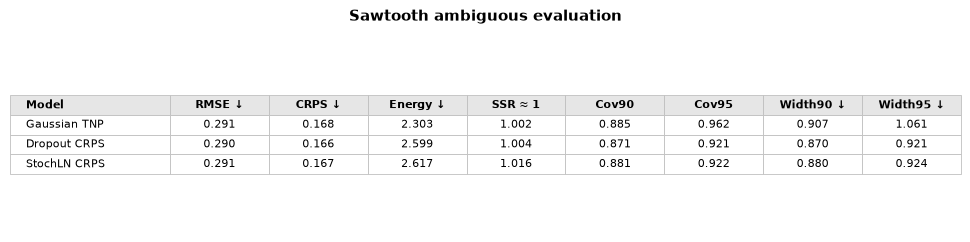

Saved: /scratch2/ij292/tnp-crps/results/synthetic_1d/sawtooth_ambiguous_eval/sawtooth_ambiguous_summary_table.png
Saved: /scratch2/ij292/tnp-crps/results/synthetic_1d/sawtooth_ambiguous_eval/sawtooth_ambiguous_summary_table.pdf


In [4]:
render_table(
    summary_table,
    title="Sawtooth ambiguous evaluation",
    output_stem="sawtooth_ambiguous_summary_table",
    font_size=8,
    header_font_size=8,
    row_height=0.42,
    width_per_col=1.02,
    model_col_width=1.65,
)


In [5]:
# Interpolation / extrapolation split table

split = metrics_raw[
    (metrics_raw["context_bucket"] == "all")
    & (metrics_raw["region"].isin(["interpolation", "extrapolation"]))
].copy()

assert len(split) == 6, (
    "Expected 6 split rows: 3 models × 2 regions. "
    f"Found {len(split)} rows. Check region/context_bucket filtering."
)

split["Model"] = split["model_name"].map(display_model_name)

wide = split.pivot_table(
    index="Model",
    columns="region",
    values=["rmse_pooled", "crps", "energy_score"],
    aggfunc="first",
)

wide = wide.reset_index()
wide = wide.sort_values("Model", key=lambda s: s.map(model_sort_key))

split_table = pd.DataFrame({
    "Model": wide["Model"],
    "RMSE Int ↓": wide[("rmse_pooled", "interpolation")].map(format_metric),
    "RMSE Ext ↓": wide[("rmse_pooled", "extrapolation")].map(format_metric),
    "CRPS Int ↓": wide[("crps", "interpolation")].map(format_metric),
    "CRPS Ext ↓": wide[("crps", "extrapolation")].map(format_metric),
    "Energy Int ↓": wide[("energy_score", "interpolation")].map(format_metric),
    "Energy Ext ↓": wide[("energy_score", "extrapolation")].map(format_metric),
})

split_table


,Model,RMSE Int ↓,RMSE Ext ↓,CRPS Int ↓,CRPS Ext ↓,Energy Int ↓,Energy Ext ↓
1,Gaussian TNP,0.290,0.291,0.168,0.168,0.554,2.230
0,Dropout CRPS,0.290,0.290,0.166,0.166,0.619,2.516
2,StochLN CRPS,0.290,0.291,0.166,0.167,0.624,2.534


In [ ]:
render_table(
    split_table,
    title="Sawtooth ambiguous interpolation / extrapolation split",
    output_stem="sawtooth_ambiguous_inter_extra_table",
    font_size=8,
    header_font_size=8,
    row_height=0.42,
    width_per_col=1.08,
    model_col_width=1.65,
)
